In [1]:
import sys

print(sys.executable)
print(sys.version)

C:\AximSoft_Weekly_Tasks\week_11\venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from collections import Counter
from nltk.corpus import stopwords
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")


In [5]:
data = pd.read_csv("../dataset/IMDB Dataset.csv")

print("Shape:", data.shape)

Shape: (50000, 2)


In [6]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
data.sample(5, random_state=42)

,review,sentiment
33553,I really liked this Summerslam due to the look...,positive
9427,Not many television shows appeal to quite as m...,positive
199,The film quickly gets to a major chase scene w...,negative
12447,Jane Austen would definitely approve of this o...,positive
39489,Expectations were somewhat high for me when I ...,negative


In [8]:
print(data["sentiment"].unique())
print(data["sentiment"].nunique())

<StringArray>
['positive', 'negative']
Length: 2, dtype: str
2


In [27]:
data.isnull().sum()

review             0
sentiment          0
word_count         0
character_count    0
dtype: int64

In [9]:
sentiment_counts = data["sentiment"].value_counts()
print(sentiment_counts)

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [10]:
sentiment_percentages = (
    data["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentages)

sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


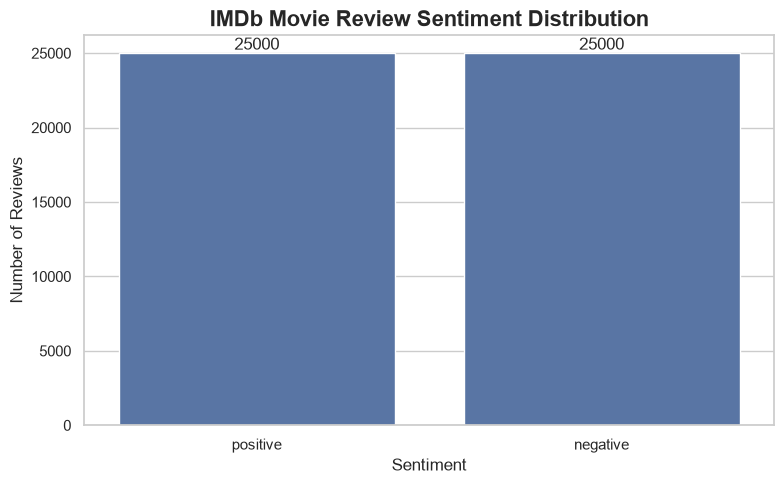

In [11]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=data,
    x="sentiment"
)

plt.title(
    "IMDb Movie Review Sentiment Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../images/sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
print(data.isnull().sum())

review       0
sentiment    0
dtype: int64


In [13]:
print("Duplicate rows:", data.duplicated().sum())
print("Duplicate reviews:", data["review"].duplicated().sum())

Duplicate rows: 418
Duplicate reviews: 418


In [14]:
duplicate_percentage = (
    data["review"].duplicated().sum()
    / len(data)
    * 100
)

print(
    f"Duplicate review percentage: "
    f"{duplicate_percentage:.2f}%"
)

Duplicate review percentage: 0.84%


In [15]:
data["word_count"] = data["review"].str.split().str.len()
data["character_count"] = data["review"].str.len()

In [16]:
print("Minimum words :", data["word_count"].min())
print("Maximum words :", data["word_count"].max())
print("Mean words    :", round(data["word_count"].mean(), 2))
print("Median words  :", data["word_count"].median())
print("Std deviation :", round(data["word_count"].std(), 2))

Minimum words : 4
Maximum words : 2470
Mean words    : 231.16
Median words  : 173.0
Std deviation : 171.34


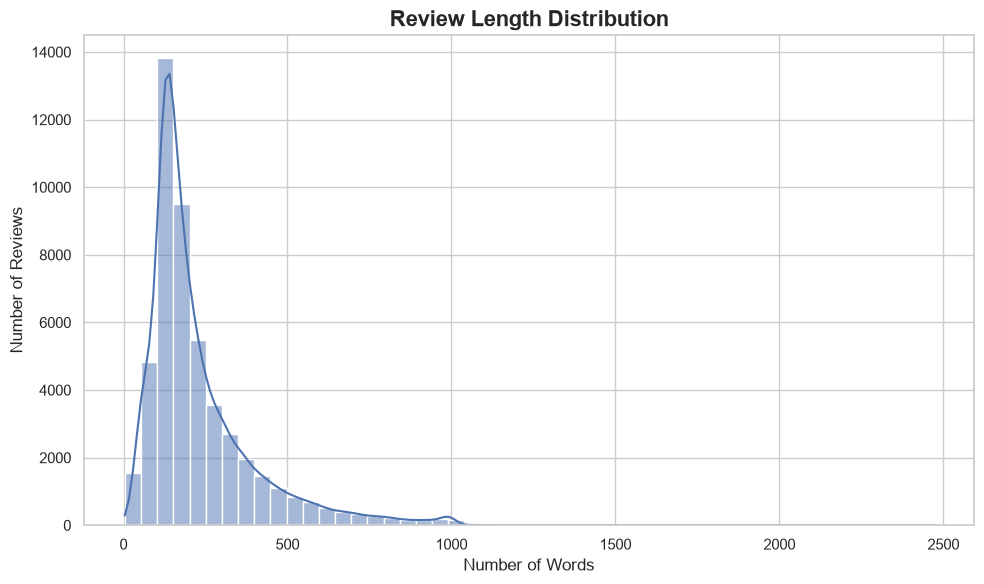

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="word_count",
    bins=50,
    kde=True
)

plt.title(
    "Review Length Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.savefig(
    "../images/review_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SURYA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [19]:
stop_words = set(stopwords.words("english"))
print("Number of English stopwords:", len(stop_words))

Number of English stopwords: 198


In [20]:
def clean_text(text):
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [21]:
all_words = []

for review in data["review"]:

    cleaned_review = clean_text(review)

    words = [
        word
        for word in cleaned_review.split()
        if word not in stop_words
        and len(word) > 2
    ]

    all_words.extend(words)

word_counts = Counter(all_words)

top_words = word_counts.most_common(20)

top_words

[('movie', 87972),
 ('film', 79708),
 ('one', 53603),
 ('like', 40172),
 ('good', 29753),
 ('time', 25109),
 ('even', 24872),
 ('would', 24602),
 ('story', 23121),
 ('really', 23095),
 ('see', 23029),
 ('well', 21269),
 ('much', 19320),
 ('bad', 18473),
 ('get', 18422),
 ('people', 18188),
 ('great', 18145),
 ('also', 17977),
 ('first', 17583),
 ('made', 16152)]

In [22]:
top_words_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,movie,87972
1,film,79708
2,one,53603
3,like,40172
4,good,29753
5,time,25109
6,even,24872
7,would,24602
8,story,23121
9,really,23095


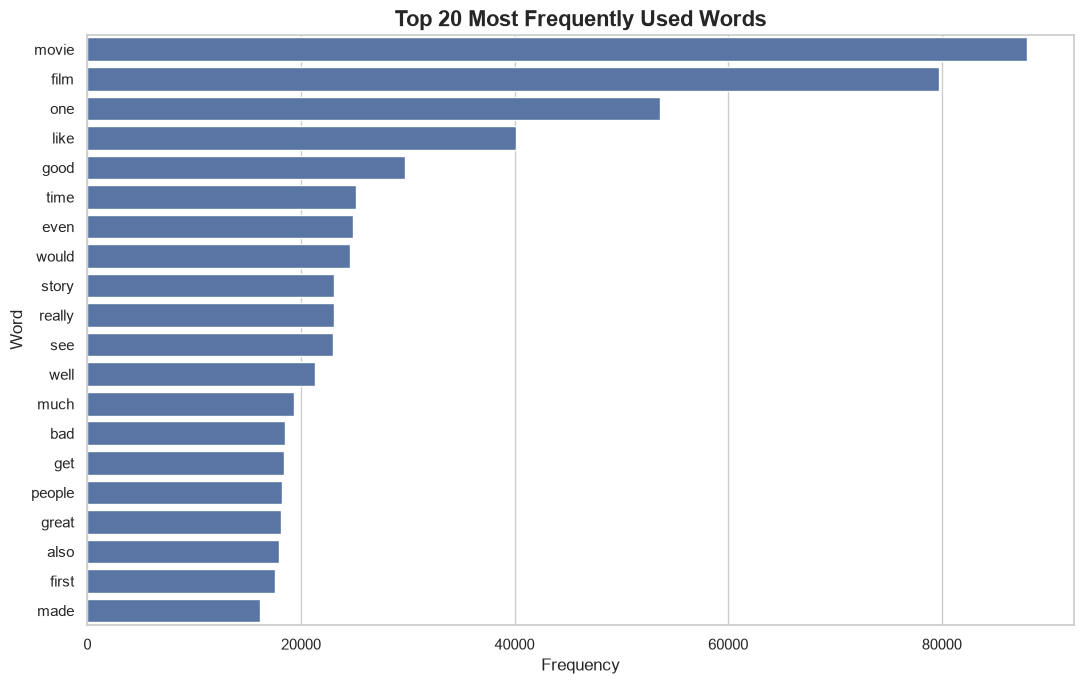

In [23]:
# word frequency visualization
plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_words_df,
    x="Frequency",
    y="Word"
)

plt.title(
    "Top 20 Most Frequently Used Words",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()

plt.savefig(
    "../images/word_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# word cloud
all_text = " ".join(all_words)

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=150,
    collocations=False
).generate(all_text)

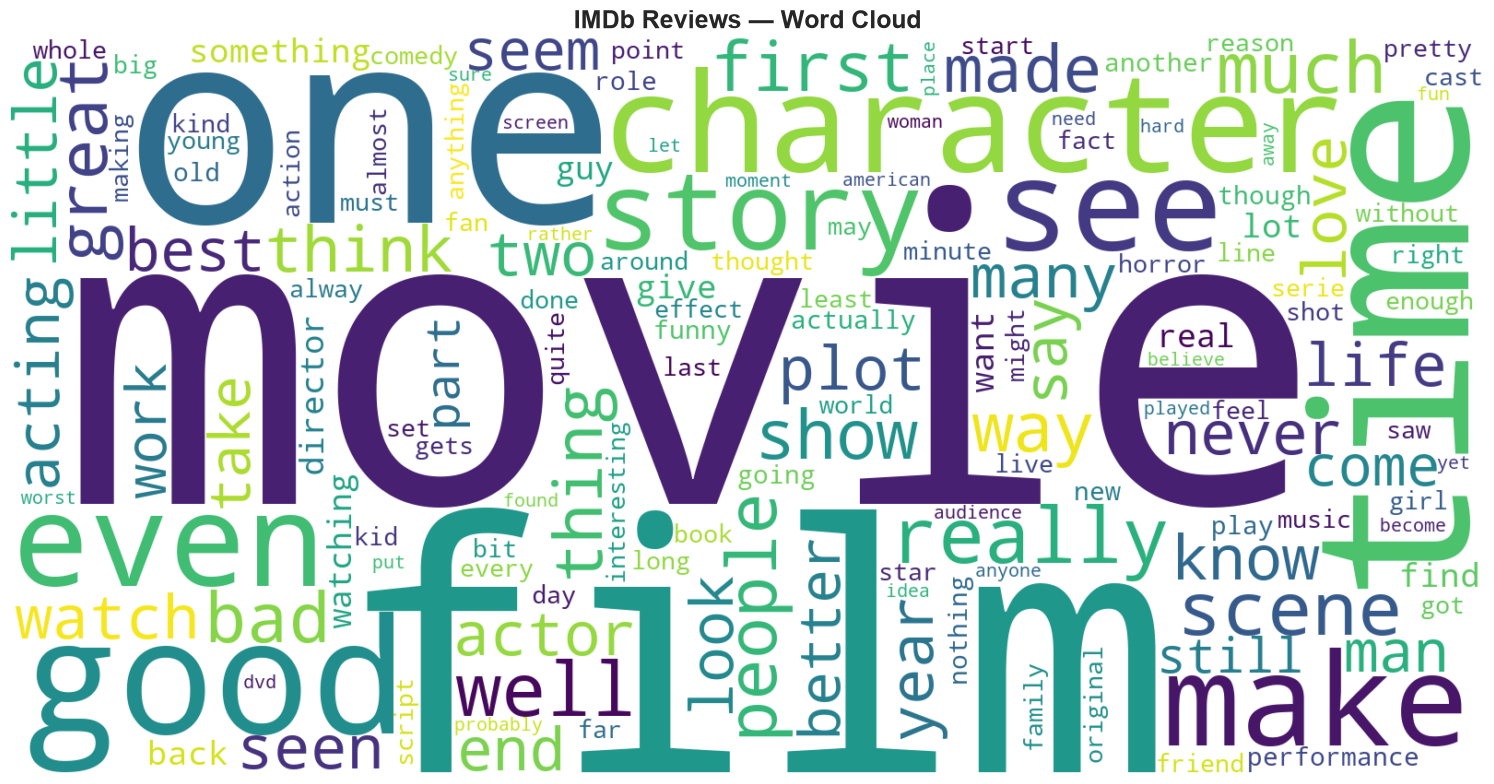

In [25]:
plt.figure(figsize=(16, 8))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "IMDb Reviews — Word Cloud",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../images/wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()